### Ejemplo de Reparto de Coste Unitario para el juego de la *Cadena* de Myerson

Se tata de la situación de comnicación de Myerson representado por la cadena abajo dibujada. La matriz de adyacencia de este grafo es la siguiente:

$$ \begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0
\end{bmatrix} $$

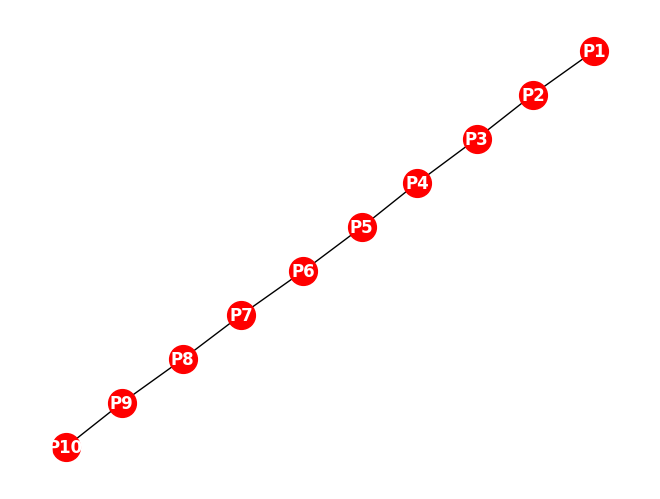

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import shap

adjacency = pd.DataFrame([
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
])
index = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7",
    "P8",
    "P9",
    "P10",
]
adjacency.columns = index
adjacency["index"] = index
adjacency = adjacency.set_index("index", verify_integrity=True)

g = nx.from_pandas_adjacency(adjacency)
pos = nx.kamada_kawai_layout(g)
nx.draw(
    g, pos, with_labels=True,
    node_color="red", font_color="white",
    font_weight="bold", node_size=400
)

In [2]:
import os
import sys
import math
import pandas as pd


file_root_shapley = os.path.join(
    "..", "..", "data", "exact", "shapley_cost_value_of_myerson_chain.csv"
)
file_root_grabisch = os.path.join(
    "..", "..", "data", "exact", "grabisch_of_myerson_chain.csv"
)

index = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7",
    "P8",
    "P9",
    "P10",
]
shapley_only = pd.read_csv(
    file_root_shapley,
    sep=";",
    header=None,
    names=["value"]
)
shapley_only["player"] = index
psi_1 = shapley_only.set_index("player", verify_integrity=True)

r_1 = pd.read_csv(
    file_root_grabisch,
    sep=";",
    header=0
)
r_1.columns = index
r_1["player"] = index
r_1 = r_1.set_index("player", verify_integrity=True)

### Truncated characteristic values

In [3]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r


n = 4
psi_1_truncated = psi_1.copy()
psi_1_truncated["value"] = psi_1_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_1_truncated = r_1.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

psi_2 = normalize_psi(psi_1)
psi_2_truncated = psi_2.copy()
psi_2_truncated["value"] = psi_2_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_2 = normalize_r(r_1)
r_2_truncated = r_2.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


#### Cost Allocation Results

The Shapley values for this game are calculated in the file ./data/exact/shapley_value_of_myerson_coalitions_chain.csv. In the table below we represent these values:

In [4]:
psi_1_truncated

,value
player,
P1,-0.5
P2,0.0
P3,0.0
P4,0.0
P5,0.0
P6,0.0
P7,0.0
P8,0.0
P9,0.0


In [5]:
psi_2_truncated

,value
player,
P1,-1.0
P2,0.0
P3,0.0
P4,0.0
P5,0.0
P6,0.0
P7,0.0
P8,0.0
P9,0.0


The Grabisch values of all the pairs in the game can be found in the file ./data/exact/grabisch_of_myerson_coalitions_chain.csv. In the following table, we represent these values.

In [6]:
r_1_truncated

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
player,,,,,,,,,,
P1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
P4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
P5,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
P6,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
P7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
P8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
P9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [7]:
r_2_truncated

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
player,,,,,,,,,,
P1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
P4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
P5,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
P6,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
P7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
P8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
P9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [8]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3] 

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 0, \beta^{-} = 0}^{2}$

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:91: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(filter_edge)
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:92: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adjacency = r.copy().applymap(lambda x: 1 if x != 0 else 0)


Saving the graph to ../../results/Cap3/Fig11.jpg


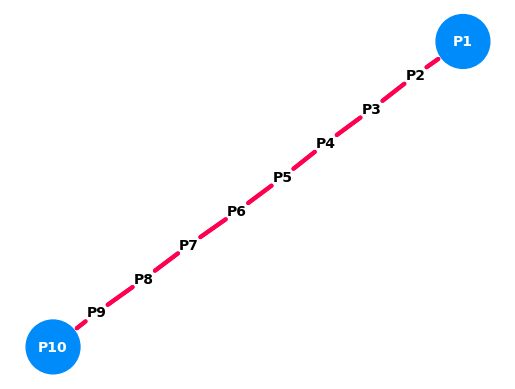

In [9]:
import os
import sys

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=0,
    positive_beta=0,
    negative_beta=0,
    symmetric=True,
    layout="kamada_kawai",
    positive_color=positive_color,
    negative_color=negative_color,
    output_path=os.path.join('..', '..', 'results', 'Cap3', 'Fig11.jpg')
)